In [1]:
import numpy as np

import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics

from collections import deque

In [43]:



def print_nn_state(network):
    for key in network.state_dict.keys():
        if not key.startswith('_'):
            layer = network.state_dict[key]
            print(f'{key} input: ', layer._last_input)
            print(f'{key} weights: \n', layer.state_dict['weights'])
            print(f'{key} bias: ', layer.state_dict['bias'])
            print(f'{key} output: ', layer._last_output)
            print('=' * 60)


def tanh_activation(layer, x):
    """ Applies TanH activation """
    layer._a_output = np.tanh(x)
    layer._grad_fn = 'tanh'
    return layer._a_output


def tanh_derivative(x):
    return 1 - np.tanh(x)


def relu_activation(layer, x):
    """ Applies ReLU activation function and tracks it """
    layer._a_output = np.maximum(0, x)
    layer._grad_fn = 'relu'
    return layer._a_output


def relu_derivative(x):
    return (x > 0).astype(float)


def softplus_activation(layer, x):
    """ Computes the Softplus activation function: ln(1 + e^x) """
    layer._grad_fn = 'softplus'
    x = np.clip(x, -50, 50)
    return np.log1p(np.exp(x))  # log1p is numerically stable for small x


def softplus_derivative(x):
    """ Computes the derivative of Softplus, which is the Sigmoid function """
    return 1 / (1 + np.exp(-x))


def log_probability(x, mu, sigma):
    """ Computes the log probability of a sample x under a normal distribution with mean mu and std sigma. """
    return -0.5 * (np.log(2 * np.pi) + 2 * np.log(sigma) + ((x - mu) ** 2) / (sigma ** 2))


def gaussian_entropy(sigma):
    """ Computes the entropy of a Gaussian distribution with standard deviation sigma. """
    return 0.5 * (np.log(2 * np.pi * np.e * sigma ** 2))


def compute_gae(next_value: list[int], rewards, dones: list[tuple[bool, bool]], values: list[int], gamma: float,
                lam: float) -> tuple[float, float]:
    """
    Compute Generalized Advantage Estimation (GAE).
    """
    values = values + [next_value]
    gae = 0  # Initial value of the advantage
    returns = deque([])
    advantages = deque([])

    for step in reversed(range(len(rewards))):
        delta = rewards[step] + gamma * values[step + 1] * (1 - dones[step]) - values[step]
        gae = delta + gamma * lam * (1 - dones[step]) * gae
        returns.appendleft(gae + values[step])
        advantages.appendleft(gae)

    # Normalize advantages
    advantages = np.array(advantages)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-6)

    # returns = (returns - np.mean(returns)) / (np.std(returns) + 1e-6)

    return np.array(returns).squeeze(), advantages.squeeze()


def mse(predicted, true):
    diff = np.clip(predicted - true, -1e6, 1e6)  # Clip extreme values
    return np.mean(diff ** 2)  # Remove division by true.size


class Memory:
    def __init__(self):
        self.states = []
        self.rewards = []
        self.dones = []
        self.log_probs = []
        self.actions = []
        self.critic_values = []

    def clear(self):
        for key in self.__dict__.keys():
            self.__dict__[key].clear()


import numpy as np

class Bias:
    def __init__(self, h_size: int, init_value: float = 0.0) -> None:
        self._h_size = h_size
        # Often, biases are simply initialized to zero.
        self._value = np.full((1, h_size), init_value)

    @property
    def value(self):
        return self._value

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class Weight:
    def __init__(self, v_size: int, h_size: int, method: str = "xavier") -> None:
        self._v_size = v_size
        self._h_size = h_size
        self.method = method.lower()
        self._value = None

    @property
    def value(self):
        if self._value is None:
            self._value = self._generate_value()
        return self._value

    def _generate_value(self):
        if self.method == "xavier":
            # Xavier/Glorot initialization
            limit = np.sqrt(6 / (self._v_size + self._h_size))
            return np.random.uniform(-limit, limit, size=(self._v_size, self._h_size))
        elif self.method == "he":
            # He initialization (recommended for layers with ReLU activations)
            std = np.sqrt(2 / self._v_size)
            return np.random.randn(self._v_size, self._h_size) * std
        else:
            # Fallback to a default uniform distribution
            return np.random.uniform(-0.5, 0.5, size=(self._v_size, self._h_size))

    def __call__(self):
        return self.value

    def __repr__(self):
        return str(self.__dict__)


class LinearLayer:
    def __init__(self, in_features: int, out_features: int, require_grad=True):
        self.in_features = in_features
        self.out_features = out_features
        self.bias = Bias(out_features)()
        self.weights = Weight(in_features, out_features)()
        self._input = None  # store input values either activated or not
        self._z_output = None  # Store output before activation
        self._a_output = None  # Store output after activation
        self._grad_fn: str = None  # tracks activated function type

    @property
    def state_dict(self):
        return dict(
            weights=self.weights,
            bias=self.bias,
        )

    def forward(self, x):
        """ Linear transformation W.X + B """
        self._input = x  # save the input
        self._z_output = np.dot(self._input, self.weights) + self.bias  # save values before activation
        return self._z_output

    def backward(self, dldy, lr):
        """ Backpropagate gradients and update weights & bias """
        # ensure numpy array
        if isinstance(self._input, list):
            self._input = np.array(self._input)

            # Ensure dldy has the correct shape
        if np.isscalar(dldy):
            dldy = np.full_like(self._z_output, dldy)  # Expand scalar loss

        elif dldy.shape != self._z_output.shape:
            dldy = dldy.reshape(self._z_output.shape)  # Align shapes

        # Compute gradient of weights and activations
        if self._a_output is None:  # No activation applied (e.g., output layer)
            dw = np.dot(self._input.T, dldy)  # Gradient of weights
            da = np.dot(dldy, self.weights.T)  # Gradient of activations for previous layer

            # Compute gradient of bias (sum over batch)
            db = np.sum(dldy, axis=0, keepdims=True)
        else:  # activation applied
            derivative_mapper = {
                'tanh': tanh_derivative,
                'relu': relu_derivative,
                'softplus': softplus_derivative,
            }
            derivative = self._grad_fn

            dZ = dldy * derivative_mapper[derivative](self._z_output)  # Apply derivative
            dw = np.dot(self._input.T, dZ)  # Compute weight gradients
            da = np.dot(dZ, self.weights.T)  # Compute activation gradients for previous layer

            # Compute gradient of bias (sum over batch)
            db = np.sum(dZ, axis=0, keepdims=True)

        grad_norm = np.linalg.norm(dw)
        if grad_norm > MAX_GRAD_NORM and grad_norm != 0:
            dw = dw * (MAX_GRAD_NORM / grad_norm)
        elif grad_norm == 0:
            dw = np.zeros_like(dw)  # Prevent division by zero

        # Update weights and biases using gradient descent
        self.weights -= lr * dw  # Correct weight update
        self.bias -= lr * db  # Correct bias update

        return da  # Return gradient for previous layer

    def __call__(self, x):
        if x is None:
            return self.state_dict
        else:
            return self.forward(x)

    def __repr__(self):
        return str(self.state_dict)


class NeuralNetwork:
    def __init__(self, lr: float = 4e-3):
        self._lr = lr

    @property
    def state_dict(self):
        return self.__dict__

    def _get_layers(self):
        return [self.state_dict[key] for key in self.state_dict.keys() if not key.startswith('_')]

    def forward(self, x):
        raise NotImplementedError('The forward() method must be implemented')

    def backward(self, policy_loss, value_loss, entropy_loss):
        losses = [policy_loss, ENT_COEF * entropy_loss, VF_COEF * value_loss]
        # losses = [policy_loss, entropy_loss, value_loss]
        output_layers = [self.mu, self.sigma, self.value]
        inner_layers = [self.hidden_layer, self.input_layer]

        separate_gradiens = []
        for layer, loss in zip(output_layers, losses):
            dldlayer = layer.backward(loss, lr=self._lr)
            separate_gradiens.append(dldlayer)

        # get mean gradient
        total_gradient = np.sum(separate_gradiens, axis=0)  # Sum gradients instead of taking mean


        for layer in inner_layers:
            total_gradient = layer.backward(total_gradient, lr=self._lr)

    def __call__(self, x):
        return self.forward(x)

    def __repr__(self):
        return self.state_dict


class MountainCar(NeuralNetwork):
    def __init__(self, action_space_dim, observation_space_dim):
        super().__init__()

        self.input_layer = LinearLayer(observation_space_dim, 64)
        self.hidden_layer = LinearLayer(64, 64)

        # actor network
        self.mu = LinearLayer(64, action_space_dim)
        self.sigma = LinearLayer(64, action_space_dim)

        # critic network
        self.value = LinearLayer(64, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = tanh_activation(self.input_layer, x)
        x = self.hidden_layer(x)
        x = tanh_activation(self.hidden_layer, x)

        mu = self.mu(x)
        mu = tanh_activation(self.mu, mu)  # generating distribution in range (-1, 1)

        sigma = self.sigma(x)
        sigma = softplus_activation(self.sigma, sigma).clip(min=1e-1,
                                                            max=3)  # std deviation, always positive, not larger than the set value

        value = self.value(x)  # no activation of the critic network
        value = tanh_activation(self.value, value)

        return mu, sigma, value

    def act(self, state):
        """ return action, log_pi and value """
        mu, sigma, value = self.forward(state)

        # draw action from the distribution
        action = np.random.normal(mu, sigma)
        action = np.tanh(action)

        # Compute log probability with Jacobian correction
        log_prob = log_probability(action.squeeze(), mu.squeeze(), sigma.squeeze())
        # log_prob = np.sum(log_prob, axis=-1)
        # log_prob -= np.sum(np.log(1 - action ** 2 + epsilon), axis=-1)  # Jacobian correction

        return action, log_prob.squeeze(), value.squeeze()

    def evaluate(self, state, action):
        mu, sigma, value = self.forward(state)

        # Reverse the tanh transformation safely

        action = np.array(action).squeeze()  # Prevent NaN in arctanh

        z = np.arctanh(action).clip(-0.999, 0.999)  # Inverse transformation

        # Compute log probability with Jacobian correction
        log_prob = log_probability(z.squeeze(), mu.squeeze(), sigma.squeeze())
        # log_prob = np.sum(log_prob, axis=-1)
        # log_prob -= np.sum(np.log(1 - action ** 2 + epsilon), axis=-1)  # Apply Jacobian correction

        # Compute entropy
        entropy = gaussian_entropy(sigma)
        entropy = np.sum(entropy, axis=-1)  # Sum over dimensions if multi-action

        return entropy.squeeze(), log_prob.squeeze(), value.squeeze()


def train(agent, env, episodes=10, epochs=8):
    memory = Memory()
    total_losses = []
    total_reward = []
    total_length = []
    for episode in range(episodes):
        memory.clear()
        episode_reward = 0
        episode_length = 0
        state, _ = env.reset()

        while True:
            action, log_prob, value = agent.act(state)

            state, reward, terminated, truncated, _ = env.step(action[0])

            done = terminated or truncated
            memory.states.append(state)
            memory.rewards.append(reward)
            memory.actions.append(action)
            memory.dones.append(done)
            memory.critic_values.append(value)
            memory.log_probs.append(log_prob)

            episode_reward += reward
            episode_length += 1

            if terminated or truncated:
                break

        # Log episode reward and length
        # writer.add_scalar("Episode/Reward", episode_reward, episode)
        # writer.add_scalar("Episode/Length", episode_length, episode)

        # when the episoed is completed, calculate the GAE
        if terminated:
            next_value = 0
        elif truncated:
            _, _, next_value = agent.act(state)

        returns, advantages = compute_gae(
            next_value=next_value,
            rewards=memory.rewards,
            dones=memory.dones,
            values=memory.critic_values,
            gamma=GAMMA,
            lam=LAMBDA,
        )

        if terminated:
            epochs = 12
        else:
            epochs = 4

        for epoch in range(epochs):
            kl_stopped = False
            # for each episode collected, perform update of the policy
            entropies, new_probs, new_values = agent.evaluate(memory.states, memory.actions)

            # probability ratio
            old_probs = np.array(memory.log_probs)
            ratio = np.exp(new_probs - old_probs)  # Prevent large updates

            # clipped surrogate loss
            clipped_loss = ratio.clip(min=1 - CLIP_EPS, max=1 + CLIP_EPS)

            # calculate policy loss
            # return ratio, advantages, clipped_loss
            policy_loss = -np.minimum(ratio * advantages, clipped_loss * advantages)

            # early stopping if KL divergence is too high
            kl_approx = (old_probs - new_probs).mean()
            if kl_approx > 1.5 * KL_TARGET:
                print(f"Early stopping update: KL divergence {kl_approx.item():.4f} exceeds threshold")
                kl_stopped = True
                break  # exit the update loop early for this epoch

            # calculate clipped value loss
            old_values = memory.critic_values

            values_clipped = old_values + np.clip(new_values - old_values, -CLIP_VF, +CLIP_VF)

            value_loss_unclipped = (new_values - returns) ** 2
            value_loss_clipped = (values_clipped - returns) ** 2

            value_loss = np.minimum(value_loss_unclipped, value_loss_clipped)

            # entropy loss
            entropy_loss = -entropies

            total_loss = policy_loss.mean() + VF_COEF * value_loss.mean() + ENT_COEF * entropy_loss.mean()

            total_losses.append(total_loss)
            # backward the loss
            agent.backward(policy_loss, value_loss, entropy_loss)

        if not kl_stopped:
            total_reward.append(episode_reward)
            total_length.append(episode_length)
            print(f'Episode: {episode}, Loss: {total_loss}, Reward: {episode_reward}')

    return total_losses, total_reward, total_length

In [44]:
GAMMA = 0.99
LAMBDA = 0.95
EPOCHS = 4
CLIP_EPS = 0.2
CLIP_VF = 0.2
LEARNING_RATE = 5e-5
LR_DECAY = 0.99
ENT_START = 0.2
ENT_END = 0.05
ENT_COEF = 0.2
VF_COEF = 1 # this sets the weight of the value function when calculating total loss
MAX_GRAD_NORM = 0.9 # clipping of the gradients 
KL_TARGET = 0.5
BATCH_SIZE = 10
epsilon = 1e-6  # To avoid log(0) issues

In [45]:
# %matplotlib inline
# %load_ext tensorboard

# %tensorboard --logdir ./custom_ppo_algo/ --host=0.0.0.0

In [46]:
env = gym.make("MountainCarContinuous-v0", render_mode="rgb_array", goal_velocity=0)
action_space_dim = env.action_space.shape[0]
observation_space_dim = env.observation_space.shape[0]

In [47]:
agent = MountainCar(action_space_dim, observation_space_dim)

In [48]:
losses, rewards, length = train(agent, env, episodes=5000, epochs=8)

Early stopping update: KL divergence 1.2430 exceeds threshold
Episode: 1, Loss: 162.75760837940226, Reward: 59.56672435485626
Episode: 2, Loss: 0.7009935894620319, Reward: -76.01430177477592
Episode: 3, Loss: 0.6902911184915387, Reward: -75.36935283365466
Episode: 4, Loss: 0.7078815182223582, Reward: -76.23398399542707
Episode: 5, Loss: 99.03692714349145, Reward: 33.5716801456979
Episode: 6, Loss: 314.5713411197158, Reward: 79.22684438297775
Episode: 7, Loss: 97.69285644439087, Reward: 31.85610858655926
Episode: 8, Loss: 0.7200860481875185, Reward: -76.71847117228506
Episode: 9, Loss: 0.7124586606524309, Reward: -76.56891991084164
Episode: 10, Loss: 0.7014426997745534, Reward: -76.15900007209294
Episode: 11, Loss: 0.7326508998645306, Reward: -76.85735185136136
Episode: 12, Loss: 0.6602625298731711, Reward: -74.8372277830563
Episode: 13, Loss: 0.6749892593907937, Reward: -75.28623051319414
Episode: 14, Loss: 0.6389324430489477, Reward: -74.33589326649953
Episode: 15, Loss: 109.505089160

KeyboardInterrupt: 

In [49]:
%matplotlib inline
import matplotlib.pyplot as plt

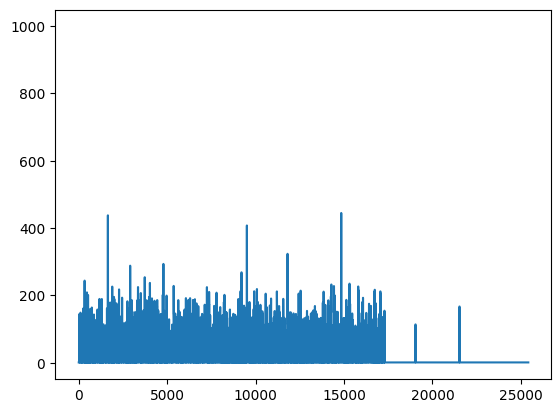

In [50]:
plt.plot(losses)
plt.plot(rewards, length)

In [35]:
losses

[np.float64(1.1259512888773349),
 np.float64(1.1259512953824535),
 np.float64(1.125951301881466),
 np.float64(1.125951308374381),
 np.float64(1.159002162431048),
 np.float64(1.1590021611867156),
 np.float64(1.159002159942111),
 np.float64(1.1590021586972337),
 np.float64(1.1742724403775056),
 np.float64(1.1742724343256374),
 np.float64(1.1742724282655546),
 np.float64(1.1742724221972407),
 np.float64(1.1910365082854804),
 np.float64(1.1910365046775147),
 np.float64(1.1910365010722404),
 np.float64(1.1910364974696543),
 np.float64(1.1295040699658478),
 np.float64(1.129504062630874),
 np.float64(1.1295040553055407),
 np.float64(1.1295040479898284),
 np.float64(1.232168510914505),
 np.float64(1.2321685109706282),
 np.float64(1.2321685110267493),
 np.float64(1.232168511082868),
 np.float64(1.216675724565607),
 np.float64(1.216675712427936),
 np.float64(1.2166757002594475),
 np.float64(1.2166756880600245),
 np.float64(1.2156399184037514),
 np.float64(1.2156399134338338),
 np.float64(1.21563